In [ ]:
import re
from pathlib import Path
import pandas as pd

In [ ]:
base_dir = Path("../data/CTD")
imida_dir = base_dir / "IMIDA"
upct_dir = base_dir / "UPCT"
out_dir = base_dir / "merged"
out_dir.mkdir(parents=True, exist_ok=True)

imida_files = {p.name: p for p in imida_dir.glob("*.csv")}
upct_files = {p.name: p for p in upct_dir.glob("*.csv")}
common_names = sorted(set(imida_files).intersection(upct_files))

for name in common_names:
    df_imida = pd.read_csv(imida_files[name])
    df_upct = pd.read_csv(upct_files[name])

    date_col = df_imida.columns[0]
    if date_col != df_upct.columns[0]:
        raise ValueError(f"Date column mismatch in {name}: "
                         f"{df_imida.columns[0]} vs {df_upct.columns[0]}")

    df_imida = df_imida.rename(
        columns={c: f"{c}_imida" for c in df_imida.columns if c != date_col}
    )
    df_upct = df_upct.rename(
        columns={c: f"{c}_upct" for c in df_upct.columns if c != date_col}
    )

    merged = pd.merge(
        df_imida,
        df_upct,
        on=date_col,
        how="outer"
    )

    merged.to_csv(out_dir / name, index=False)

print(f"Merged files saved to: {out_dir}")



Found 24 matching CSVs to merge.
Merged files saved to: ..\data\CTD\merged


In [13]:
merged_dir = Path("../data/CTD/merged")
out_dir = Path("../data/CTD/merged")
out_dir.mkdir(parents=True, exist_ok=True)

def normalize_col(col: str) -> str:
    if col.strip().lower() == "date":
        return "Date"

    col = col.strip()

    dataset = None
    if col.lower().endswith("_imida"):
        dataset = "imida"
    elif col.lower().endswith("_upct"):
        dataset = "upct"

    m = re.search(r"(-?\d+(?:\.\d+)?)", col)
    depth = None
    if m:
        depth = float(m.group(1))

    if dataset is None or depth is None:
        return col

    depth_str = f"{abs(depth):.1f}"

    return f"{depth_str}_{dataset}"

csv_files = list(merged_dir.glob("*_turbidity.csv")) + list(merged_dir.glob("*_transparency.csv"))

for csv_path in csv_files:
    df = pd.read_csv(csv_path)
    df.columns = [normalize_col(c) for c in df.columns]
    df.to_csv(out_dir / csv_path.name, index=False)

print(f"Renamed files saved to: {out_dir}")


Renamed files saved to: ..\data\CTD\merged


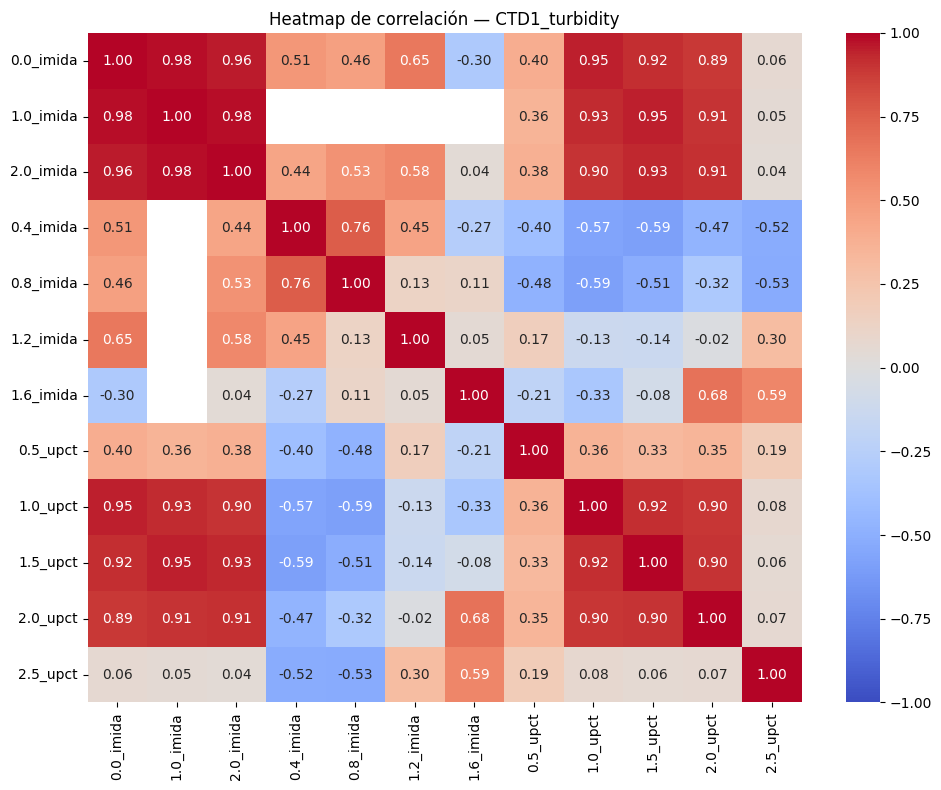

['0.0_imida', '1.0_imida', '1.0_upct', '1.5_upct', '2.0_imida', '2.0_upct']
['0.4_imida']
['0.5_upct']
['0.8_imida']
['1.2_imida']
['1.6_imida']
['2.5_upct']


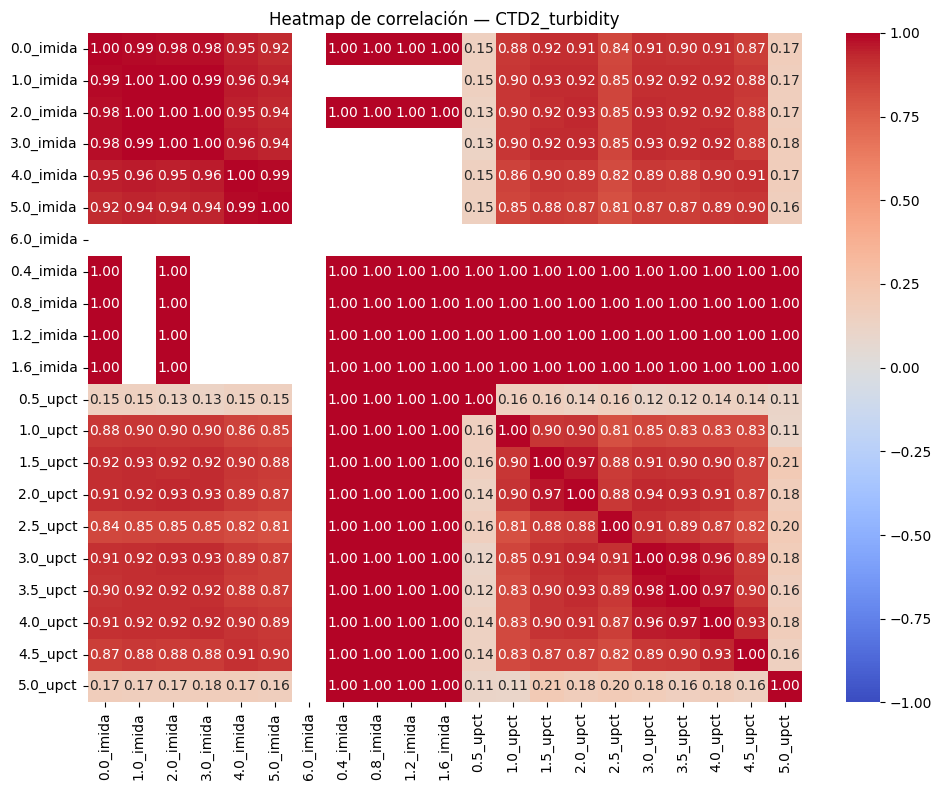

['0.0_imida', '0.4_imida', '0.5_upct', '0.8_imida', '1.0_imida', '1.0_upct', '1.2_imida', '1.5_upct', '1.6_imida', '2.0_imida', '2.0_upct', '2.5_upct', '3.0_imida', '3.0_upct', '3.5_upct', '4.0_imida', '4.0_upct', '4.5_upct', '5.0_imida', '5.0_upct']
['6.0_imida']


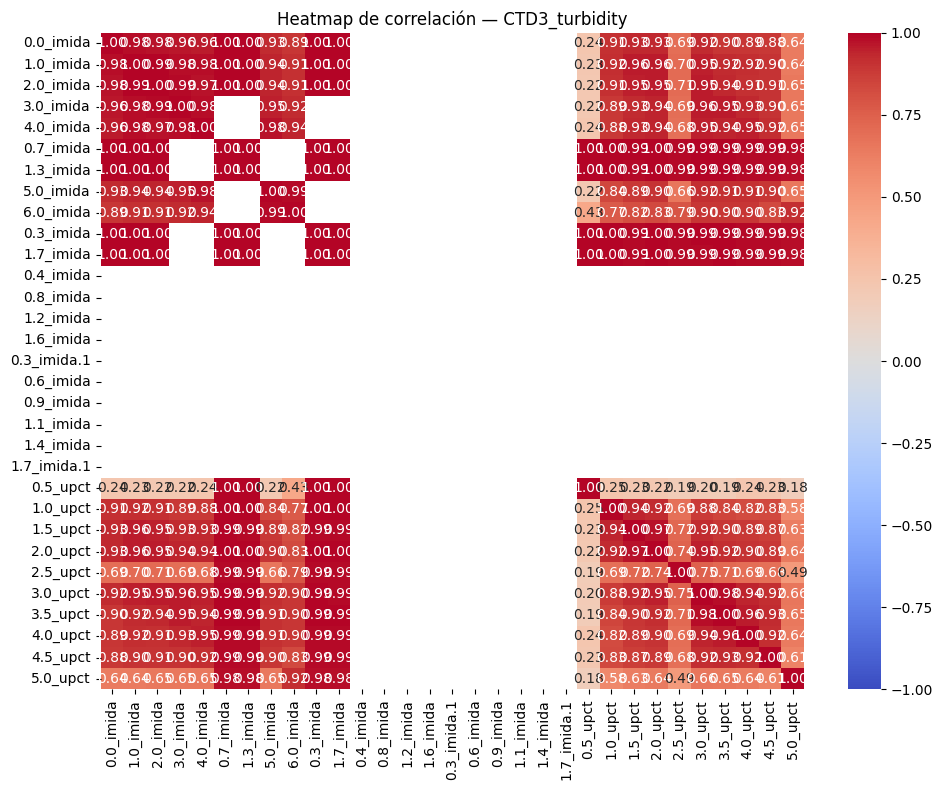

['0.0_imida', '0.3_imida', '0.5_upct', '0.7_imida', '1.0_imida', '1.0_upct', '1.3_imida', '1.5_upct', '1.7_imida', '2.0_imida', '2.0_upct', '2.5_upct', '3.0_imida', '3.0_upct', '3.5_upct', '4.0_imida', '4.0_upct', '4.5_upct', '5.0_imida', '5.0_upct', '6.0_imida']
['0.3_imida.1']
['0.4_imida']
['0.6_imida']
['0.8_imida']
['0.9_imida']
['1.1_imida']
['1.2_imida']
['1.4_imida']
['1.6_imida']
['1.7_imida.1']


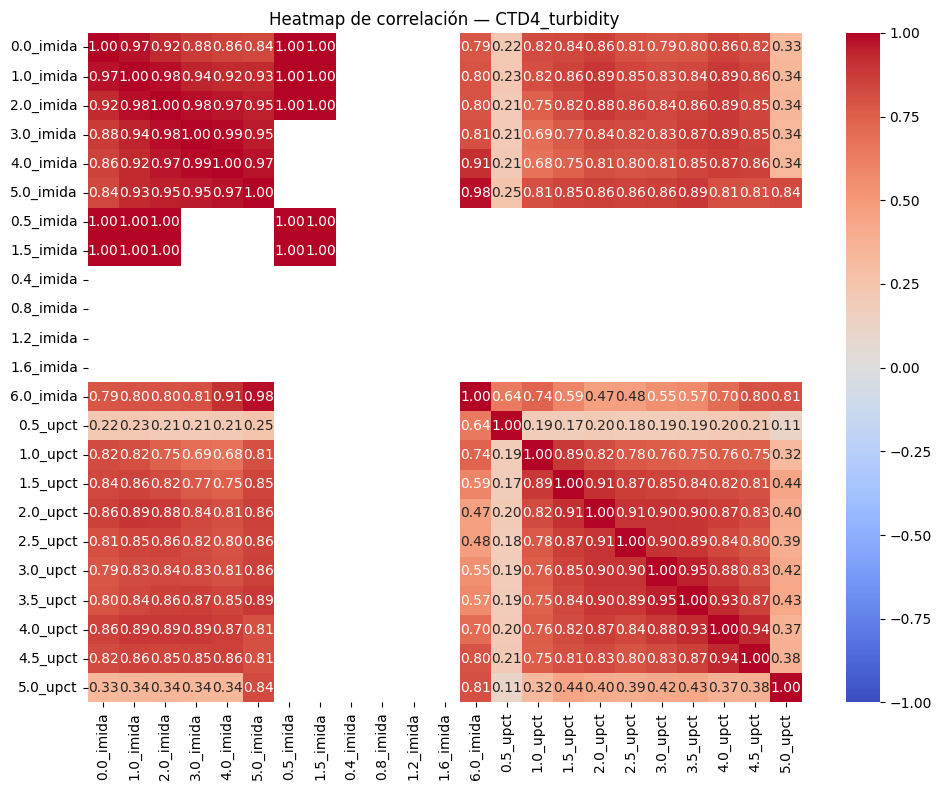

['0.0_imida', '0.5_imida', '1.0_imida', '1.5_imida', '2.0_imida', '3.0_imida', '4.0_imida', '5.0_imida', '6.0_imida']
['1.5_upct', '2.0_upct', '2.5_upct', '3.0_upct', '3.5_upct', '4.0_upct', '4.5_upct']
['0.4_imida']
['0.5_upct']
['0.8_imida']
['1.0_upct']
['1.2_imida']
['1.6_imida']
['5.0_upct']


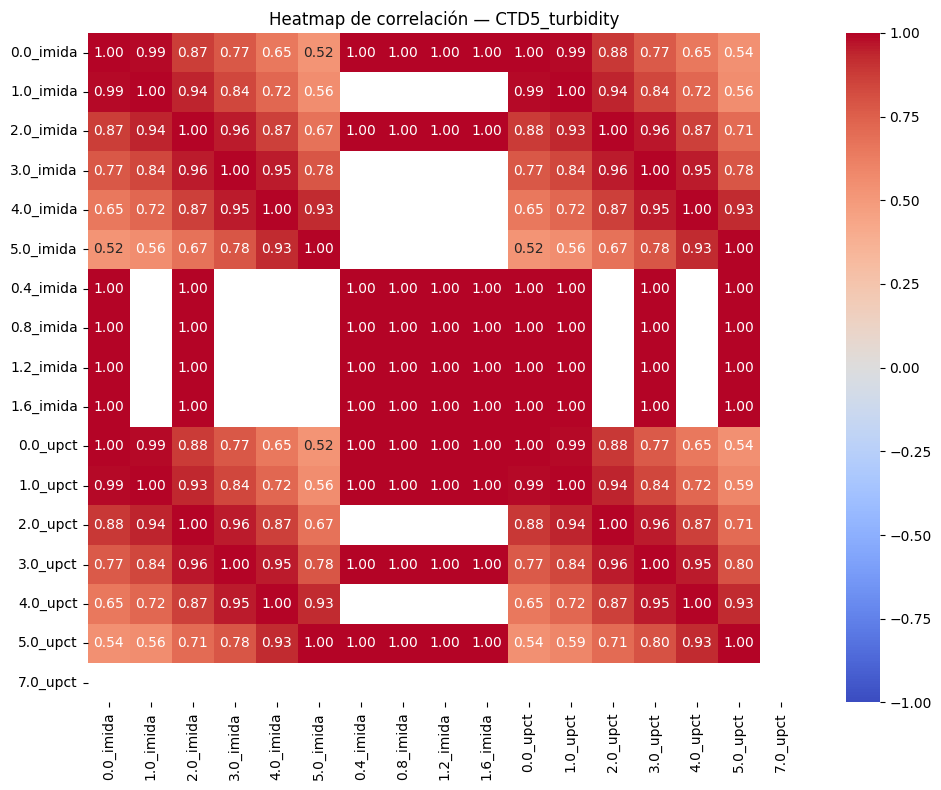

['0.0_imida', '0.0_upct', '0.4_imida', '0.8_imida', '1.0_imida', '1.0_upct', '1.2_imida', '1.6_imida', '2.0_imida', '2.0_upct', '3.0_imida', '3.0_upct', '4.0_imida', '4.0_upct', '5.0_imida', '5.0_upct']
['7.0_upct']


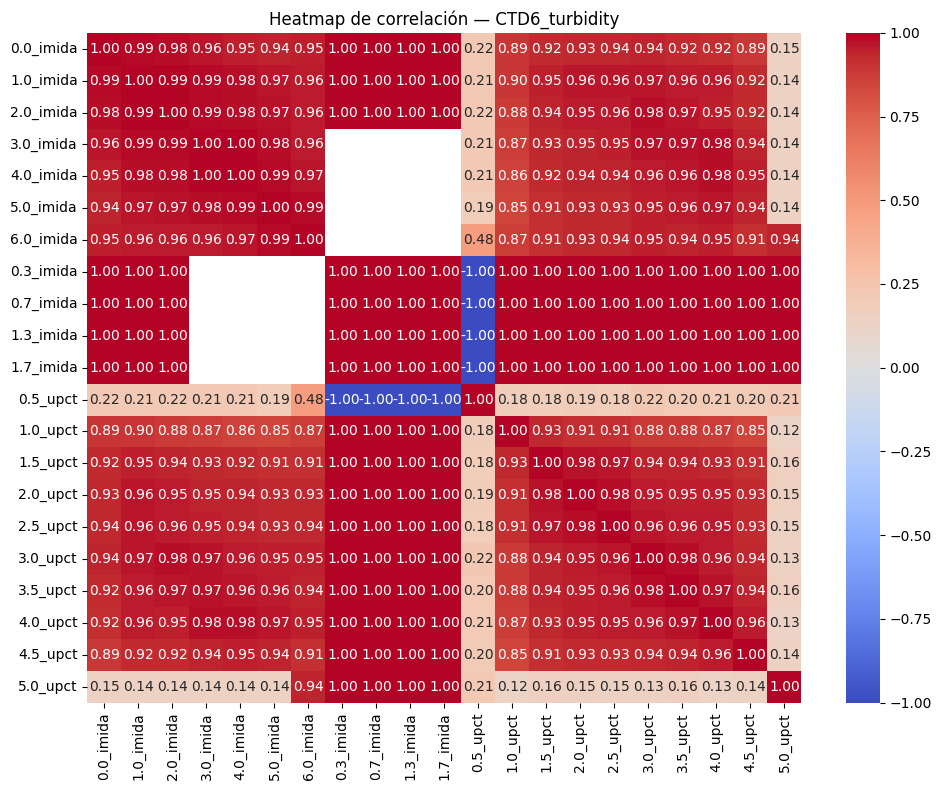

['0.0_imida', '0.3_imida', '0.5_upct', '0.7_imida', '1.0_imida', '1.0_upct', '1.3_imida', '1.5_upct', '1.7_imida', '2.0_imida', '2.0_upct', '2.5_upct', '3.0_imida', '3.0_upct', '3.5_upct', '4.0_imida', '4.0_upct', '4.5_upct', '5.0_imida', '5.0_upct', '6.0_imida']


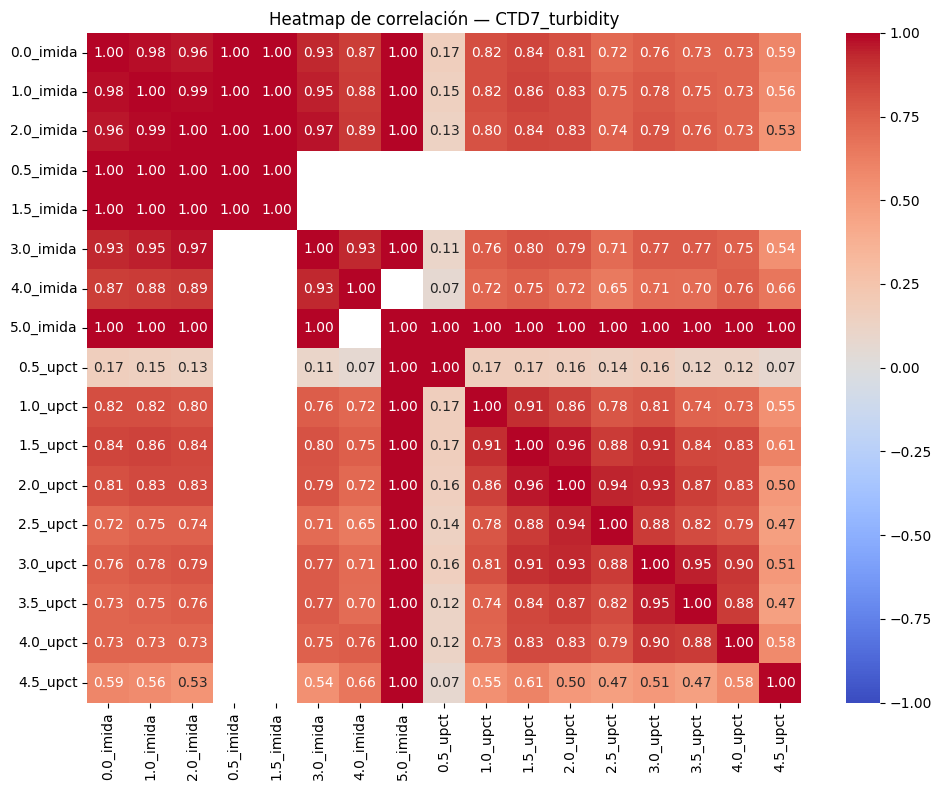

['0.0_imida', '0.5_imida', '0.5_upct', '1.0_imida', '1.0_upct', '1.5_imida', '1.5_upct', '2.0_imida', '2.0_upct', '2.5_upct', '3.0_imida', '3.0_upct', '3.5_upct', '4.0_imida', '4.0_upct', '4.5_upct', '5.0_imida']


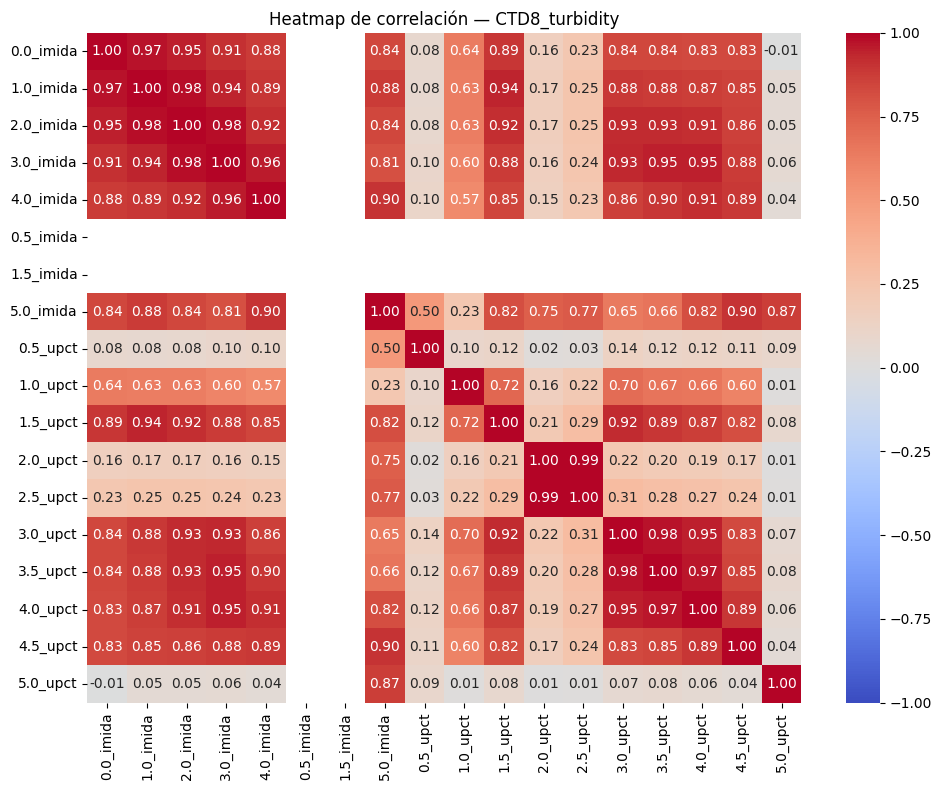

['0.0_imida', '1.0_imida', '1.5_upct', '2.0_imida', '3.0_imida', '3.0_upct', '3.5_upct', '4.0_imida', '4.0_upct']
['2.0_upct', '2.5_upct']
['0.5_imida']
['0.5_upct']
['1.0_upct']
['1.5_imida']
['4.5_upct']
['5.0_imida']
['5.0_upct']


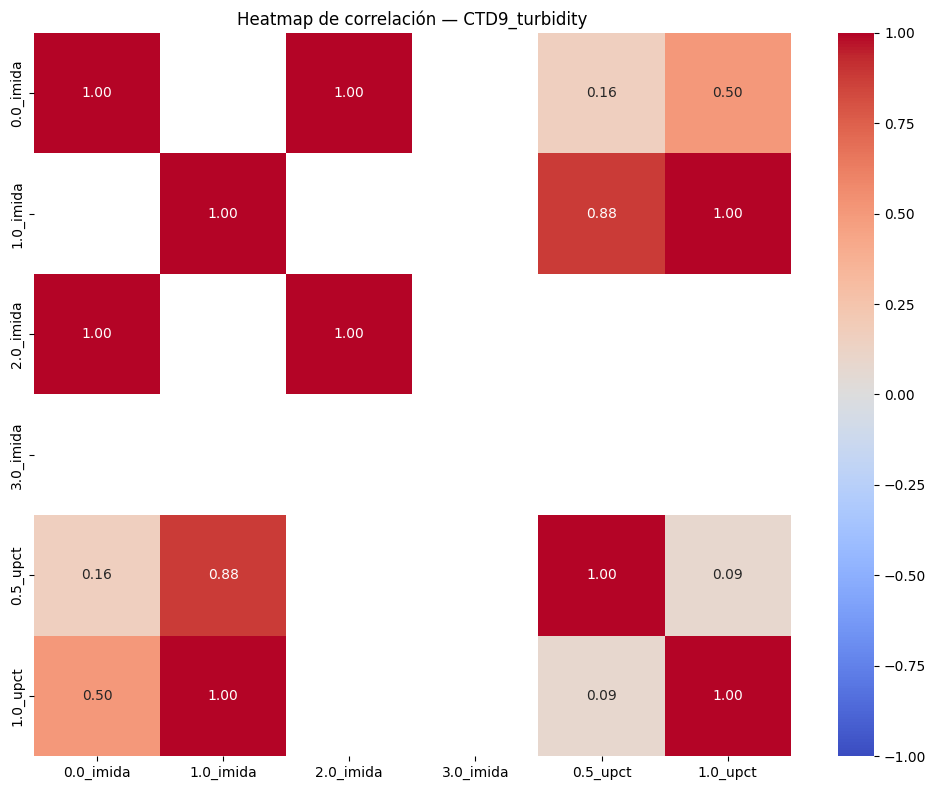

['0.0_imida', '2.0_imida']
['1.0_imida', '1.0_upct']
['0.5_upct']
['3.0_imida']


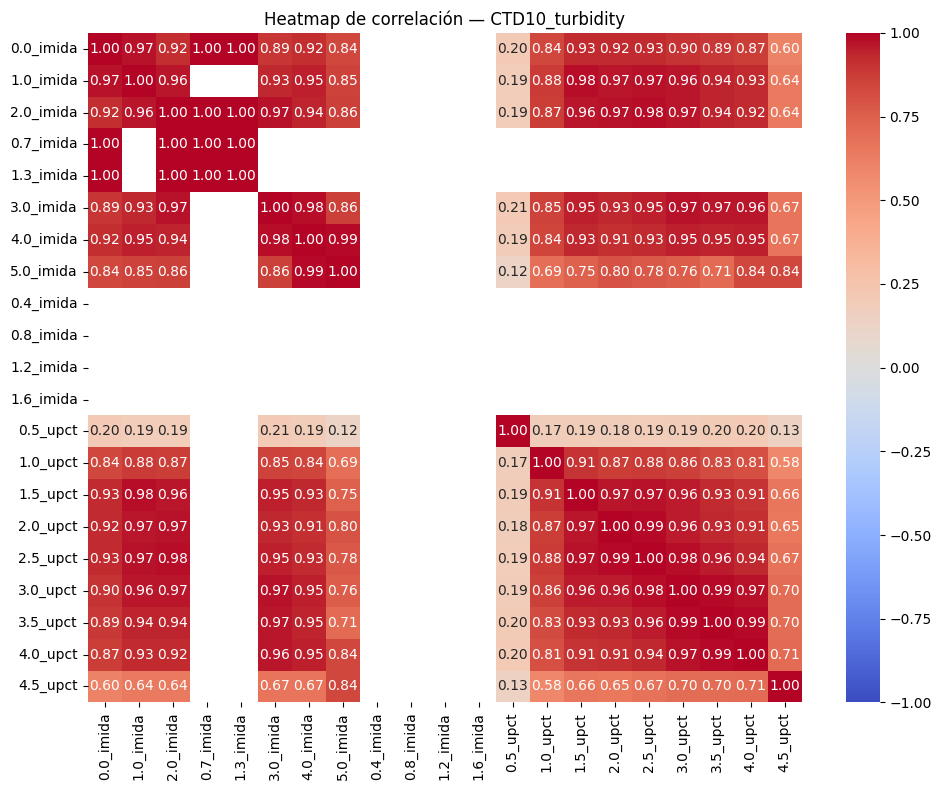

['0.0_imida', '0.7_imida', '1.0_imida', '1.0_upct', '1.3_imida', '1.5_upct', '2.0_imida', '2.0_upct', '2.5_upct', '3.0_imida', '3.0_upct', '3.5_upct', '4.0_imida', '4.0_upct', '5.0_imida']
['0.4_imida']
['0.5_upct']
['0.8_imida']
['1.2_imida']
['1.6_imida']
['4.5_upct']


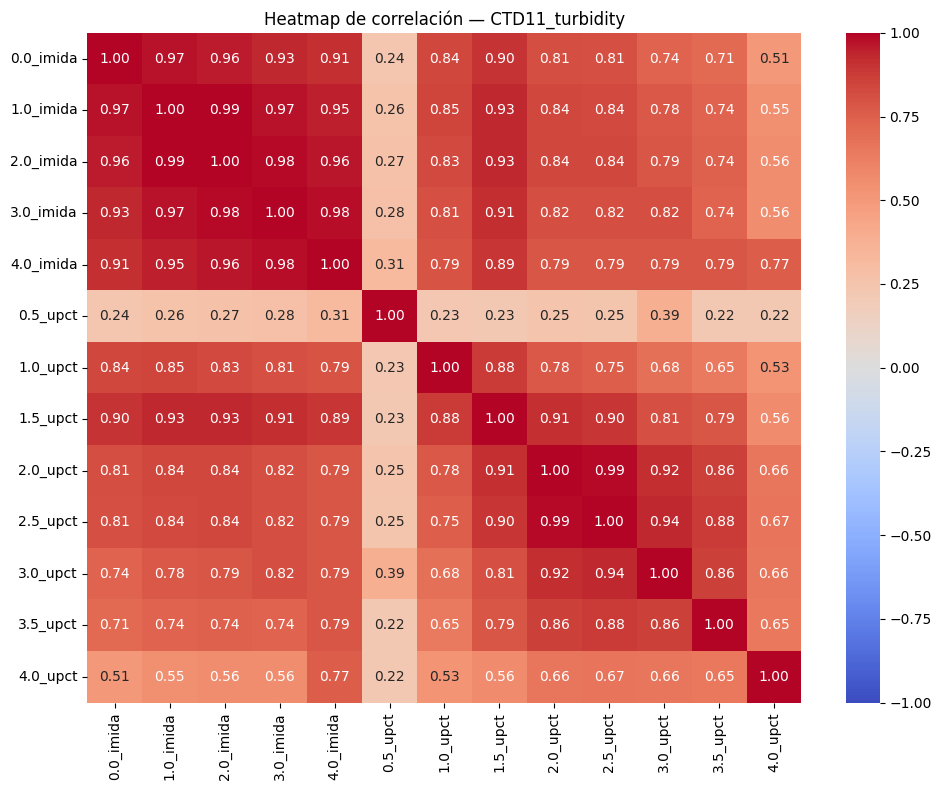

['0.0_imida', '1.0_imida', '1.5_upct', '2.0_imida', '2.0_upct', '2.5_upct', '3.0_imida', '3.0_upct', '4.0_imida']
['0.5_upct']
['1.0_upct']
['3.5_upct']
['4.0_upct']


In [19]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

for i in range(1, 12):
    csv_path = f"../data/CTD/merged/CTD{i}_turbidity.csv"
    df = pd.read_csv(csv_path)

    date_cols = [c for c in df.columns if c.strip().lower() == "date"]
    if date_cols:
        df = df.drop(columns=date_cols)

    df_num = df.select_dtypes(include="number")

    corr = df_num.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
    plt.title(f"Heatmap de correlaci﷿﷿n ﷿﷿﷿ CTD{i}_turbidity")
    plt.tight_layout()
    plt.show()
    cols = list(corr.columns)
    threshold = 0.9

    parent = {c: c for c in cols}
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for i, c1 in enumerate(cols):
        for j in range(i+1, len(cols)):
            c2 = cols[j]
            if abs(corr.loc[c1, c2]) >= threshold:
                union(c1, c2)

    groups = {}
    for c in cols:
        r = find(c)
        groups.setdefault(r, []).append(c)

    groups_list = sorted([sorted(g) for g in groups.values()], key=lambda x: (-len(x), x))
    for g in groups_list:
        print(g)

In [12]:
for i in range(1, 12):
    csv_path = f"../data/CTD/merged/CTD{i}_turbidity.csv"
    df = pd.read_csv(csv_path)
    
    date_cols = [c for c in df.columns if c.strip().lower() == "date"]
    if date_cols:
        df = df.drop(columns=date_cols)
    
    df_num = df.select_dtypes(include="number")
    corr = df_num.corr()
    
    upct_cols = [c for c in corr.columns if "upct" in c.lower()]
    imida_cols = [c for c in corr.columns if "imida" in c.lower()]
    
    threshold = 0.9
    
    print(f"\nArchivo: CTD{i}_turbidity.csv")
    print("-" * 50)
    
    for upct_col in upct_cols:
        high_corr = []
        for imida_col in imida_cols:
            if abs(corr.loc[upct_col, imida_col]) >= threshold:
                high_corr.append((imida_col, corr.loc[upct_col, imida_col]))
        
        if high_corr:
            high_corr.sort(key=lambda x: abs(x[1]), reverse=True)
            print(f"{upct_col}: ", end="")
            print(", ".join([f"{col} ({val:.3f})" for col, val in high_corr]))
        else:
            print(f"{upct_col}: No correlaciona con IMIDA (umbral > {threshold})")


Archivo: CTD1_turbidity.csv
--------------------------------------------------
0.5_upct: No correlaciona con IMIDA (umbral > 0.9)
1.0_upct: 0.0_imida (0.947), 1.0_imida (0.929), 2.0_imida (0.905)
1.5_upct: 1.0_imida (0.950), 2.0_imida (0.933), 0.0_imida (0.919)
2.0_upct: 2.0_imida (0.907), 1.0_imida (0.905)
2.5_upct: No correlaciona con IMIDA (umbral > 0.9)

Archivo: CTD2_turbidity.csv
--------------------------------------------------
0.5_upct: 1.6_imida (1.000), 0.8_imida (1.000), 1.2_imida (1.000), 0.4_imida (1.000)
1.0_upct: 0.4_imida (1.000), 0.8_imida (1.000), 1.2_imida (1.000), 1.6_imida (1.000)
1.5_upct: 0.8_imida (1.000), 1.2_imida (1.000), 1.6_imida (1.000), 0.4_imida (1.000), 1.0_imida (0.925), 3.0_imida (0.924), 2.0_imida (0.921), 0.0_imida (0.917)
2.0_upct: 1.6_imida (1.000), 0.8_imida (1.000), 1.2_imida (1.000), 0.4_imida (1.000), 2.0_imida (0.930), 3.0_imida (0.929), 1.0_imida (0.925), 0.0_imida (0.915)
2.5_upct: 1.6_imida (1.000), 0.8_imida (1.000), 1.2_imida (1.000), 

In [18]:
from pathlib import Path

satellite_dir = Path("../data/Satellite")
tif_files = list(satellite_dir.glob("*composite.tif"))

dates = sorted(set(
    f.name.split("_")[0] 
    for f in tif_files 
    if "_" in f.name
))

print(len(dates))
print(dates)

47
['2021-08-24', '2021-08-26', '2021-09-12', '2021-09-30', '2023-01-05', '2023-01-07', '2023-01-10', '2023-01-20', '2023-01-21', '2023-01-23', '2023-01-29', '2023-01-30', '2023-01-31', '2023-02-01', '2023-02-04', '2023-02-05', '2023-02-07', '2023-02-11', '2023-02-27', '2023-03-01', '2023-03-16', '2023-03-22', '2023-03-29', '2023-06-21', '2023-08-17', '2023-08-24', '2023-10-05', '2023-10-17', '2023-11-08', '2023-11-16', '2023-11-24', '2023-12-07', '2023-12-19', '2023-12-27', '2024-01-09', '2024-01-16', '2024-01-23', '2024-02-13', '2024-02-20', '2024-03-13', '2024-04-10', '2024-04-24', '2024-05-22', '2024-05-29', '2024-06-18', '2024-06-25', '2024-07-03']
